In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
%matplotlib inline
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pseudovelo as pv

AnnData object with n_obs × n_vars = 2341 × 23974
    obs: 'Stage', 'gt_terminal_states', 'lineages'
    uns: 'Stage_colors', 'gt_terminal_states_colors', 'lineages_colors'
    obsm: 'X_force_directed'


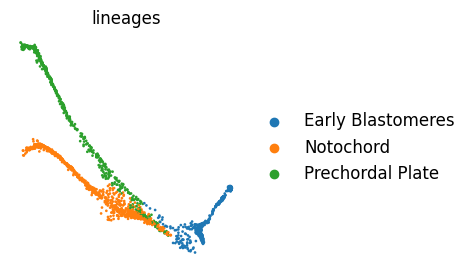

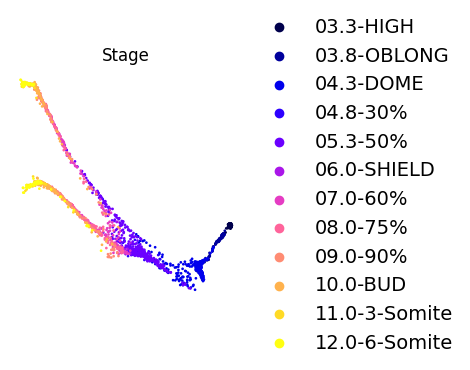

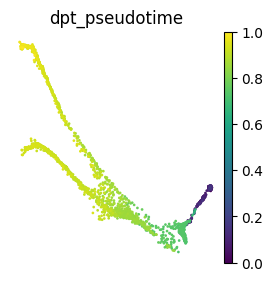

In [3]:
adata_dpt = sc.read_h5ad("../data/zebrafish/zebrafish_embryogenesis_axial_mesoderm.h5ad")
adata_dpt.obsm["X_force_directed"] = adata_dpt.obsm["X_force_directed"][:, :2]
adata_dpt = adata_dpt[~np.any(np.isnan(adata_dpt.obsm["X_force_directed"]), axis=1)].copy()
print(adata_dpt)


#cal dpt_pseudotime
sc.pp.filter_genes(adata_dpt, min_cells=10)
sc.pp.normalize_total(adata_dpt)
sc.pp.log1p(adata_dpt)
sc.pp.highly_variable_genes(adata_dpt, n_top_genes=2000)
adata_dpt = adata_dpt[:, adata_dpt.var.highly_variable].copy()
sc.tl.pca(adata_dpt)
sc.pp.neighbors(adata_dpt, n_neighbors=30, n_pcs=30)

start_cell_index = np.where(adata_dpt.obs["Stage"] == "03.3-HIGH")[0][0]
root_cell = adata_dpt.obs_names[start_cell_index]
adata_dpt.uns["iroot"] = start_cell_index
sc.tl.diffmap(adata_dpt)
sc.tl.dpt(adata_dpt)

fig, ax = plt.subplots(figsize=(3,3))
sc.pl.embedding(adata_dpt, basis="force_directed", color=["lineages"],frameon=False,ax=ax,size=15,title="lineages",legend_fontsize=12)

fig, ax = plt.subplots(figsize=(3,3))
sc.pl.embedding(adata_dpt, basis="force_directed", color=["Stage"],frameon=False,ax=ax,size=15,title="Stage",legend_fontsize=14)

fig, ax = plt.subplots(figsize=(3,3))
sc.pl.embedding(adata_dpt, basis="force_directed", color=["dpt_pseudotime"],frameon=False,ax=ax,size=15,title="dpt_pseudotime",legend_fontsize=8)

[global] J range = 1, eps = 1e-06 (eps_factor = 1e-06)
Fitting NB GLMGam per cluster, cluster_key = 'lineages', n_clusters = 3
[cluster=Early Blastomeres] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 9 (factor = 0.851), n_jobs = 10.
[cluster=Notochord] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.231), n_jobs = 10.
[cluster=Prechordal Plate] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.278), n_jobs = 10.
Stored μ in adata.layers['gam_nb_mu'] with shape (2341, 2000)
Stored dμ/dJ in adata.layers['gam_nb_dmu_dJ'] with shape (2341, 2000)


  0%|          | 0/2341 [00:00<?, ?cells/s]

computing velocity graph
finished.


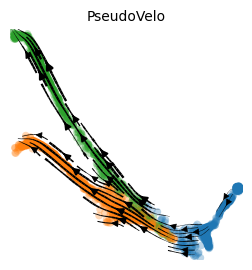

computing velocity embedding
finished.


In [4]:
#PseudoVelo
adata_dpt.layers["X"]=adata_dpt.X.toarray()
pv.fit_nb_gam_with_center_diff(adata_dpt,J_key="dpt_pseudotime",n_jobs=10,cluster_key="lineages",input_layer="X",reverse=False)
pv.plot_velocity_projection(adata_dpt,xkey="X",vkey="gam_nb_dmu_dJ",basis="force_directed",color="lineages",figsize=(3,3),title="PseudoVelo",size=120,legend_loc="none")

  0%|          | 0/2341 [00:00<?, ?cell/s]

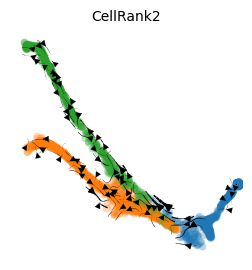

In [5]:
#cellrank2
import cellrank as cr
pk = cr.kernels.PseudotimeKernel(adata_dpt, time_key="dpt_pseudotime")
pk.compute_transition_matrix()
pk.write_to_adata()
pk.plot_projection(basis="force_directed", color="lineages",show=False,figsize=(3,3),title="CellRank2",s=120,legend_fontsize=8,legend_loc="none")
ax = plt.gca()
ax.grid(False)
plt.show()

(2341, 2)
AnnData object with n_obs × n_vars = 2341 × 23974
    obs: 'Stage', 'gt_terminal_states', 'lineages'
    uns: 'Stage_colors', 'gt_terminal_states_colors', 'lineages_colors'
    obsm: 'X_force_directed'
INFO     Initialized CellMapper for self-mapping with 2341 cells.                                                  
INFO     Self-mapping mode detected. Computing only yx neighbors for efficiency (all neighbor matrices will contain
         the same information).                                                                                    
INFO     Using sklearn to compute 30 neighbors.                                                                    
INFO     Computing mapping matrix using kernel method 'umap'.                                                      
INFO     Mapping layer for key 'X' using direct multiplication                                                     
INFO     Imputed expression matrix with shape (2341, 13635) converted to AnnData object.    

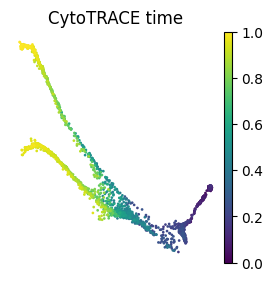

[global] J range = 1, eps = 1e-06 (eps_factor = 1e-06)
Fitting NB GLMGam per cluster, cluster_key = 'lineages', n_clusters = 3
[cluster=Early Blastomeres] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 5 (factor = 0.415), n_jobs = 10.


c:\Users\shuxin\anaconda3\envs\celldyc_test5\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


[cluster=Notochord] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 9 (factor = 0.83), n_jobs = 10.
[cluster=Prechordal Plate] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 8 (factor = 0.797), n_jobs = 10.
Stored μ in adata.layers['gam_nb_mu'] with shape (2341, 2000)
Stored dμ/dJ in adata.layers['gam_nb_dmu_dJ'] with shape (2341, 2000)


  0%|          | 0/2341 [00:00<?, ?cells/s]

computing velocity graph
finished.


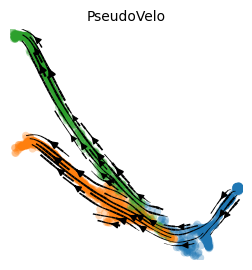

computing velocity embedding
finished.


  0%|          | 0/2341 [00:00<?, ?cell/s]

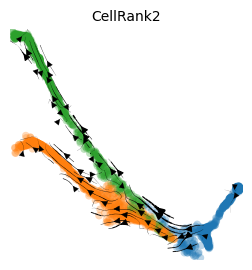

In [7]:
from cellmapper import CellMapper

#cal ct_pseudotime
adata_ct=sc.read_h5ad("../data/zebrafish/zebrafish_embryogenesis_axial_mesoderm.h5ad")
adata_ct.obsm["X_force_directed"]=adata_ct.obsm["X_force_directed"][:,:2]
adata_ct = adata_ct[~np.any(np.isnan(adata_ct.obsm['X_force_directed']), axis=1)].copy()
print(adata_ct.obsm["X_force_directed"].shape)
print(adata_ct)
adata=adata_ct.copy()
sc.pp.filter_genes(adata_ct, min_cells=10)
sc.pp.normalize_total(adata_ct)
sc.pp.log1p(adata_ct)
sc.pp.highly_variable_genes(adata_ct, n_top_genes=2000)
sc.tl.pca(adata_ct)
sc.pp.neighbors(adata_ct, n_neighbors=30, n_pcs=30)
adata_ct.layers["imputed"] = (
    CellMapper(adata_ct).map(layer_key="X", use_rep="X_pca").query_imputed.X.copy()
)
from cellrank.kernels import CytoTRACEKernel
ctk = CytoTRACEKernel(adata_ct).compute_cytotrace(layer="imputed")
fig, ax = plt.subplots(figsize=(3,3))
sc.pl.embedding(adata_ct, basis="force_directed", color="ct_pseudotime",frameon=False,ax=ax,size=15,title="CytoTRACE time",legend_fontsize=8)

#PseudoVelo
sc.pp.filter_genes(adata, min_cells=10)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var.highly_variable].copy()
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30)
adata.obs["ct_pseudotime"]=adata_ct.obs["ct_pseudotime"]
adata_ct=adata.copy()
adata_ct.layers["X"]=adata_ct.X.toarray()
pv.fit_nb_gam_with_center_diff(adata_ct,J_key="ct_pseudotime",n_jobs=10,cluster_key="lineages",input_layer="X",reverse=False)
pv.plot_velocity_projection(adata_ct,xkey="X",vkey="gam_nb_dmu_dJ",basis="force_directed",color="lineages",figsize=(3,3),title="PseudoVelo",size=120,legend_loc="none")

#cellrank2
ctk.compute_transition_matrix(threshold_scheme="soft", nu=0.5)
ctk.plot_projection(basis="force_directed",color="lineages",figsize=(3,3),title="CellRank2",size=120,legend_loc="none",show=False)
ax = plt.gca()
ax.grid(False)
plt.show()



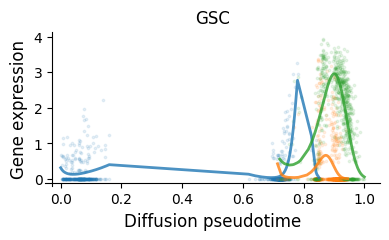

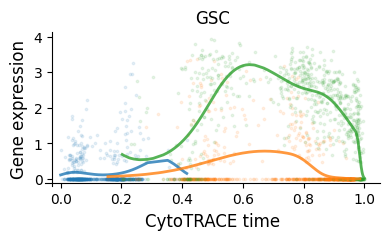

In [8]:
pv.plot_gam_fit(adata_dpt,J_key="dpt_pseudotime",mu_layer="gam_nb_mu",input_layer="X",cluster_key="lineages",gene_list=["GSC"],figsize=(4,2.5),fontsize=12,xlabel="Diffusion pseudotime")
pv.plot_gam_fit(adata_ct,J_key="ct_pseudotime",mu_layer="gam_nb_mu",input_layer="X",cluster_key="lineages",gene_list=["GSC"],figsize=(4,2.5),fontsize=12,xlabel="CytoTRACE time")

In [9]:
gene2 = "GSC"
v1_g2 = adata_dpt.layers["gam_nb_dmu_dJ"][:, adata_dpt.var_names.get_loc(gene2)]
v2_g2 = adata_ct.layers["gam_nb_dmu_dJ"][:, adata_ct.var_names.get_loc(gene2)]
sign_v1_g2 = np.sign(v1_g2)
sign_v2_g2 = np.sign(v2_g2)
g2 = (sign_v1_g2 == sign_v2_g2).sum() / len(sign_v1_g2)
print(g2)

0.7992310978214439


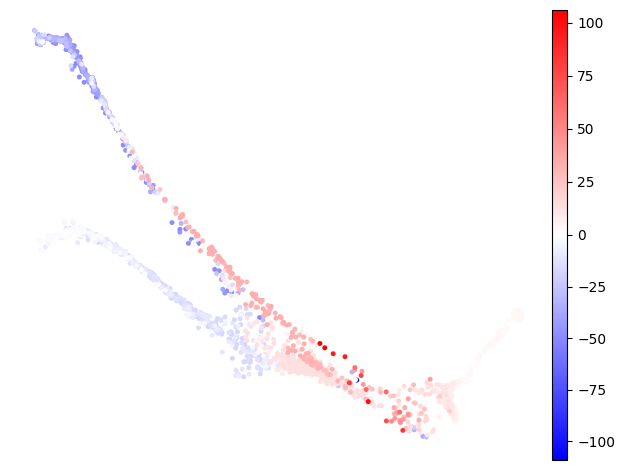

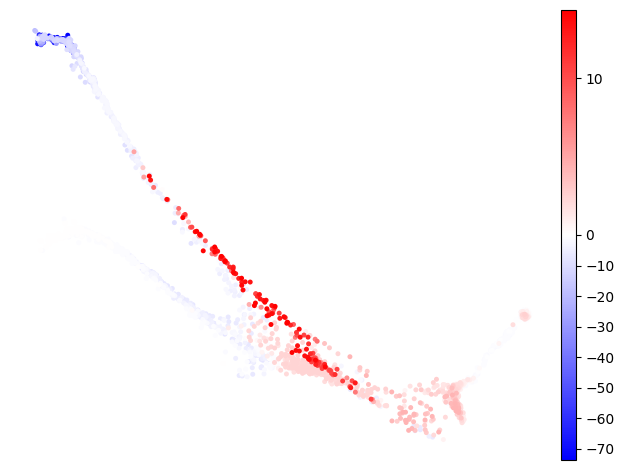

In [ ]:
obs_col_name = f"{gene2}_dmu_dJ"
adata_dpt.obs[obs_col_name] = v1_g2
adata_ct.obs[obs_col_name] = v2_g2

sc.pl.embedding(
    adata_dpt, 
    basis="force_directed",  
    color=obs_col_name,              
    show=False,              
    title="",             
    frameon=False,        
    cmap="bwr",       
    vcenter=0,legend_fontsize=18    
)
plt.tight_layout()
plt.show()         

sc.pl.embedding(
    adata_ct, 
    basis="force_directed", 
    color=obs_col_name,
    show=False,
    title="",             
    frameon=False,        
    cmap="bwr",       
    vcenter=0,legend_fontsize=18   
)
plt.tight_layout()
plt.show()